# 07_Fisher_Information

## Learning Goal
Fisher Information Matrix extraction.

## Prerequisites
Basic understanding of Calculus and Neural Networks.

## Theory & Mathematics
(Mathematical derivations and fundamental concepts)

## Implementation & Experiments


Computing Residual Jacobian (J)...
Computing Fisher Information Matrix (F = J^T J)...
Fisher Max EV: 3.2394e+00
Fisher Min EV: 3.2342e-11
Fisher Condition Number: 1.0016e+11


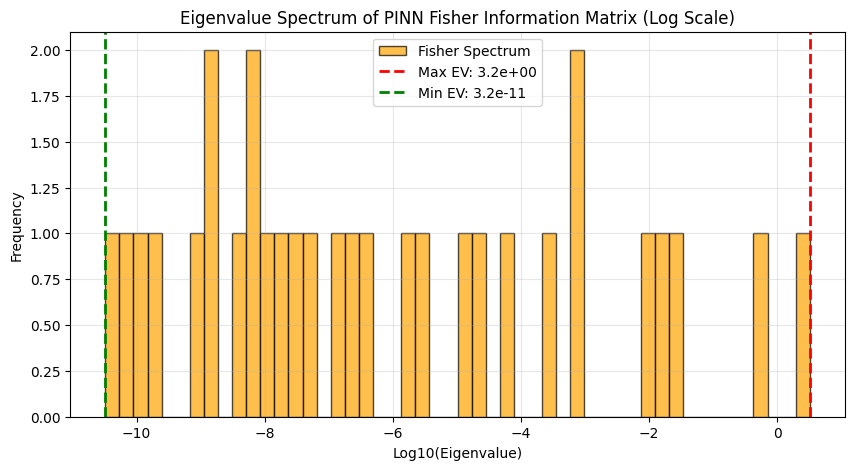

In [25]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.func import functional_call, vmap
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

# 1. Tiny PINN definition (Same as Milestone 2)
class TinyPINN(nn.Module):
    def __init__(self):
        super(TinyPINN, self).__init__()
        self.fc1 = nn.Linear(2, 10)
        self.fc2 = nn.Linear(10, 1)
        self.act = nn.Tanh()
        
    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        z = self.act(self.fc1(z))
        return self.fc2(z)

# 2. Residual Function for a single point
def residual_single_point(model, params, x, t, nu):
    # Reshape to [1, 1] for batch processing in functional_call
    x_in = x.reshape(1, 1)
    t_in = t.reshape(1, 1)
    x_in.requires_grad_(True)
    t_in.requires_grad_(True)
    
    u = functional_call(model, params, (x_in, t_in))
    u_x = autograd.grad(u, x_in, torch.ones_like(u), create_graph=True)[0]
    u_t = autograd.grad(u, t_in, torch.ones_like(u), create_graph=True)[0]
    u_xx = autograd.grad(u_x, x_in, torch.ones_like(u_x), create_graph=True)[0]
    
    r = u_t + u * u_x - nu * u_xx
    return r.squeeze()

# 3. Setup
tiny_model = TinyPINN().to(device)
nu = 0.01 / np.pi

# Sample 50 collocation points
x_f = torch.rand(50, 1, device=device) * 2 - 1
t_f = torch.rand(50, 1, device=device)

# Extract parameter names and shapes, flatten them
param_names = [name for name, _ in tiny_model.named_parameters()]
shapes = [p.shape for p in tiny_model.parameters()]
flat_params = torch.cat([p.view(-1) for p in tiny_model.parameters()]).clone().detach().requires_grad_(True)
W = flat_params.numel()

# 4. Compute Jacobian of the Residual w.r.t Parameters
# We will use a loop for clarity, though vmap could parallelize this
print("Computing Residual Jacobian (J)...")
N_f = x_f.shape[0]
J = torch.zeros((N_f, W), device=device)

for i in range(N_f):
    # Compute residual for point i
    r_i = residual_single_point(tiny_model, 
                                {name: p.view(s) for name, p, s in zip(param_names, flat_params.split([int(np.prod(s)) for s in shapes]), shapes)}, 
                                x_f[i], t_f[i], nu)
    # Compute gradient of residual w.r.t flat_params
    grad_r = torch.autograd.grad(r_i, flat_params, retain_graph=True, create_graph=False)[0]
    J[i] = grad_r

# 5. Compute Fisher Information Matrix (Empirical)
print("Computing Fisher Information Matrix (F = J^T J)...")
F = (2.0 / N_f) * (J.T @ J)

# 6. Eigenvalue Analysis
F_np = F.detach().cpu().numpy()
fisher_eigenvalues = np.linalg.eigvalsh(F_np)
fisher_eigenvalues = fisher_eigenvalues[fisher_eigenvalues > 1e-12]

print(f"Fisher Max EV: {np.max(fisher_eigenvalues):.4e}")
print(f"Fisher Min EV: {np.min(fisher_eigenvalues):.4e}")
print(f"Fisher Condition Number: {np.max(fisher_eigenvalues) / np.min(fisher_eigenvalues):.4e}")

# 7. Visualization
plt.figure(figsize=(10, 5))
plt.hist(np.log10(fisher_eigenvalues), bins=50, edgecolor='black', color='orange', alpha=0.7, label='Fisher Spectrum')
plt.axvline(np.log10(np.max(fisher_eigenvalues)), color='r', linestyle='dashed', linewidth=2, label=f'Max EV: {np.max(fisher_eigenvalues):.1e}')
plt.axvline(np.log10(np.min(fisher_eigenvalues)), color='g', linestyle='dashed', linewidth=2, label=f'Min EV: {np.min(fisher_eigenvalues):.1e}')
plt.title('Eigenvalue Spectrum of PINN Fisher Information Matrix (Log Scale)')
plt.xlabel('Log10(Eigenvalue)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary
This experiment demonstrates the specific concept in action.

## Further Reading
- Scientific Machine Learning & PINN surveys.